# Layer 2 — What response did it get?

**Business case.** The **hirer** — a talent-acquisition lead at a Singapore SME — is setting
**pay range**, **minimum years of experience**, and **position level** for a vacancy, and wants
the role to fill on the first posting rather than be reposted.

Layer 1 (`hirer_layer1_analysis.ipynb`) answered *is this configuration normal?* using all 1,044,587
postings. This notebook answers the harder half — *what applicant response did configurations like
this actually get, and which ones get reposted?*

It runs on a much smaller cohort, and §1 is entirely about earning the right to use it.

| | Layer 1 | Layer 2 (this notebook) |
|---|---|---|
| Question | What do comparable employers offer? | What response did it get? |
| Rows | 1,044,587 | 96,028 → 78,942 (see §1) |
| Window | Mar 2023 – May 2024 | Mar – Jun 2023 |

**Headline finding (§5–6):** demanding more experience is associated with *more* reposting when the
pay band is low, and slightly *less* reposting when it is not. The overall relationship, not split by pay, points
the opposite way and is a mix effect.

## 0. Setup

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.contingency_tables import StratifiedTable, Table2x2

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/processed/jobs_enriched.parquet'

MIN_N = 30            # smallest cell we will quote a benchmark from
CRAWL_DATE = '2023-07-01'   # inferred, not recorded -- see hirer_layer1_analysis.ipynb s.1

YR_BINS = [-1, 0, 1, 2, 3, 5, 8, 100]
YR_LABELS = ['0', '1', '2', '3', '4-5', '6-8', '9+']

# Pay bands, cut on salary_midpoint -- the centre of the advertised
# range rather than either endpoint. See s.1.5.
PAY_BINS = [-1, 2999, 4999, 7999, 1e12]
PAY_LABELS = ['Entry (< $3k)', 'Mid ($3-5k)', 'Senior ($5-8k)', 'Executive (> $8k)']

df = pd.read_parquet(DATA_PATH)
print(f'{len(df):,} postings loaded')

1,044,587 postings loaded


## 1. Cohort — three filters, each one earning its place

Layer 2 uses the engagement counters (`applications`, `views`, `repost_count`), and those are only
trustworthy under specific conditions. Three nested filters get us there. Each one costs rows, so
each needs a reason.

Two subsections then close the section off: §1.4 checks the one thing these filters could
plausibly have broken, and §1.5 derives `pay_band`, the variable every later split holds fixed.

### 1.1 Counters complete — drop postings whose counters were frozen mid-life

The cell first collapses the frame to one row per `dup_group_id` — the duplicate groups
established in Layer 1 — so no posting's counters are counted twice. Then the filter itself.

The dataset concatenates two collection regimes (established in `hirer_layer1_analysis.ipynb` §1). Only
postings that **expired before the crawl** have counters that finished accumulating. For everything
else the counters are frozen at roughly day 0 — those postings are not low-response, they are
**unmeasured**, and averaging them in would drag every configuration's response toward zero.

In [23]:
mkt = df.drop_duplicates(subset='dup_group_id', keep='first').copy()
mkt['counters_complete'] = mkt.expiry_date <= pd.Timestamp(CRAWL_DATE)
mkt['pay_band'] = pd.cut(mkt.salary_midpoint.astype('float64'), PAY_BINS, labels=PAY_LABELS)

settled = mkt[mkt.counters_complete].copy()
print(f'deduplicated market      {len(mkt):>9,}')
print(f'counters complete        {len(settled):>9,}  ({len(settled)/len(mkt):.1%})')

deduplicated market      1,009,709
counters complete          118,749  (11.8%)


### 1.2 Exposure comparability — keep 30-day listings only

`listing_days` varies, and it drives response mechanically: a 7-day listing simply has less time to
collect applicants than a 30-day one. Comparing configurations across different listing lengths
would confound the configuration with its exposure window.

30-day is the dominant case, so restricting costs relatively little and removes the confound
outright rather than trying to adjust for it.

In [24]:
exposure = settled.groupby('listing_days', observed=True).agg(
    n=('views', 'size'), median_views=('views', 'median'), median_apps=('applications', 'median'))
print(exposure[exposure.n >= 100].to_string())

cohort = settled[settled.listing_days == 30].copy()
print(f'\n30-day listings          {len(cohort):>9,}  ({len(cohort)/len(settled):.1%} of complete-counter)')

                  n  median_views  median_apps
listing_days                                  
7              5970          35.0          1.0
14            13860          66.0          3.0
21             2887          88.0          5.0
30            96028          78.0          4.0

30-day listings             96,028  (80.9% of complete-counter)


A 7-day listing gets roughly **half** the views of a 30-day one. That is exposure, not employer
attractiveness, and it is exactly the kind of artefact this filter removes.

### 1.3 First cycle only — for the volume outcomes

`repost_count` tells us a posting was relisted, and a relisted posting accumulates views and
applications across **several listing cycles**. Its totals are therefore not comparable with a
posting that ran once.

`repost_count` is also **top-coded at 2** (its maximum across the entire dataset), so we cannot
reliably divide totals by a cycle count to normalise. Instead we split the analysis:

* **Volume outcomes** (applications, views, conversion) → **first-cycle postings only**. This is
  also the exact question the hirer is asking: *what happens on the first posting?*
* **Repost outcome** → the full 30-day cohort, treated as the **binary** `is_repost` flag
  (`repost_count > 0`, carried in from the enriched data), where top-coding is harmless.

In [25]:
cycle_effect = cohort.groupby('repost_count', observed=True).agg(
    n=('views', 'size'), median_views=('views', 'median'), median_apps=('applications', 'median'))
print(cycle_effect.to_string())
print('\nOne repost roughly 2.4x the views -- accumulated exposure, not desirability.')

repost_pool = cohort                              # binary repost outcome (s.5-6)
first = cohort[cohort.repost_count == 0].copy()    # volume outcomes (s.3-4)
print(f'\nrepost analysis pool     {len(repost_pool):>9,}')
print(f'first-cycle pool         {len(first):>9,}')

                  n  median_views  median_apps
repost_count                                  
0             78942          67.0          3.0
1             10488         161.0          8.0
2              6598         200.0          9.0

One repost roughly 2.4x the views -- accumulated exposure, not desirability.

repost analysis pool        96,028
first-cycle pool            78,942


### 1.4 Could reposts be missed because the crawl came first?

A posting that expired on 28 Jun 2023 and was relisted on 5 Jul would be recorded with
`repost_count = 0`, because the crawl happened first. If that mattered, repost rates would sag for
postings expiring **close to** the crawl date. The check below says they do not — the rate is flat
at 17–20% right up to the boundary.

The one group that differs is postings expiring more than 60 days before the crawl (11.9%). That is
the earliest slice of the data with a different sector mix, not a censoring effect. We keep it and
note it.

In [26]:
tmp = repost_pool.copy()
tmp['days_before_crawl'] = (pd.Timestamp(CRAWL_DATE) - tmp.expiry_date).dt.days
buckets = pd.cut(tmp.days_before_crawl, [-1, 7, 14, 21, 30, 45, 60, 400])
censor = tmp.groupby(buckets, observed=True).agg(
    n=('is_repost', 'size'), repost_rate=('is_repost', 'mean')).round(3)
print(censor.to_string())

                       n  repost_rate
days_before_crawl                    
(-1, 7]            16081        0.178
(7, 14]            15280        0.189
(14, 21]           15471        0.182
(21, 30]           19615        0.185
(30, 45]            3919        0.195
(45, 60]           18058        0.178
(60, 400]           7604        0.119


### 1.5 Pay band — splitting on what is actually paid

Layer 2's central claim is about *holding pay fixed*, so the variable we split on has to
genuinely fix pay. We therefore derive **`pay_band`**: `salary_midpoint` cut at \$3k / \$5k / \$8k.

The midpoint is the right cut variable because a posting's floor and ceiling can sit far apart — a
posting advertising \$500–\$8,000 has a midpoint of \$4,250 — so banding on either endpoint alone
produces a label that much of the range contradicts. The cell below shows what each `pay_band`
holds: the midpoint partitions cleanly by construction, while the advertised floor and ceiling
spread around the label.

The cutpoints are a judgement call. §5 reports the pattern they produce; §6 tests it on the
counts directly.

In [27]:
sal = cohort.copy()
for c in ['salary_min', 'salary_midpoint', 'salary_max']:
    sal[c] = sal[c].astype('float64')

spread = sal.groupby('pay_band', observed=True).agg(
    n=('salary_midpoint', 'size'),
    min_p50=('salary_min', 'median'),
    mid_p50=('salary_midpoint', 'median'),
    max_p50=('salary_max', 'median'),
).round(0)
print('What each pay_band actually contains -- median advertised floor, midpoint and ceiling.')
print('The midpoint partitions cleanly by construction; the floor and ceiling spread around it.\n')
print(spread[spread.n > 0].to_string())

print(f'\npay_band unassigned (no salary): {cohort.pay_band.isna().sum():,}')

What each pay_band actually contains -- median advertised floor, midpoint and ceiling.
The midpoint partitions cleanly by construction; the floor and ceiling spread around it.

                       n  min_p50  mid_p50  max_p50
pay_band                                           
Entry (< $3k)      27334   2000.0   2400.0   2800.0
Mid ($3-5k)        40061   3000.0   3750.0   4400.0
Senior ($5-8k)     18376   5000.0   6000.0   7000.0
Executive (> $8k)   9518   8000.0  10000.0  12000.0

pay_band unassigned (no salary): 739


## 2. Outcomes — three of them, and why not the obvious one

`applications` is severely right-skewed and zero-inflated, so **means are actively misleading**.
A configuration whose mean is 9 can easily have a median of 3. Everything below reports medians and
percentile bands.

| Outcome | Definition | Why |
|---|---|---|
| **Under-filled risk** | `P(applications < vacancies)` | Closest thing to "did it fill?" — the hirer's actual fear |
| **Response volume** | median applications, P10–P90 | Expectation-setting, robust to the skew |
| **Repost risk** | `P(repost_count > 0)` | The stated business outcome |

**Caveat on under-filled risk.** `applications >= vacancies` does not mean the role filled — the
applicants may all be unsuitable. It is a *necessary* condition, not a sufficient one, and it is the
strongest stand-in the data supports.

In [28]:
first['under_filled'] = first.applications < first.vacancies

print('Applications, first-cycle cohort:')
print(first.applications.describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(2).to_string())
print(f'\nmean {first.applications.mean():.2f} vs median {first.applications.median():.0f}'
      '   <- why this notebook never quotes means')
print(f'zero-application rate     {(first.applications == 0).mean():.1%}')
print(f'under-filled risk         {first.under_filled.mean():.1%}')
print(f'repost rate (30-day pool) {repost_pool.is_repost.mean():.1%}')

Applications, first-cycle cohort:
count    78942.00
mean         9.61
std         21.67
min          0.00
10%          0.00
25%          1.00
50%          3.00
75%         10.00
90%         23.00
99%         99.00
max        922.00

mean 9.61 vs median 3   <- why this notebook never quotes means
zero-application rate     19.1%
under-filled risk         30.1%
repost rate (30-day pool) 17.8%


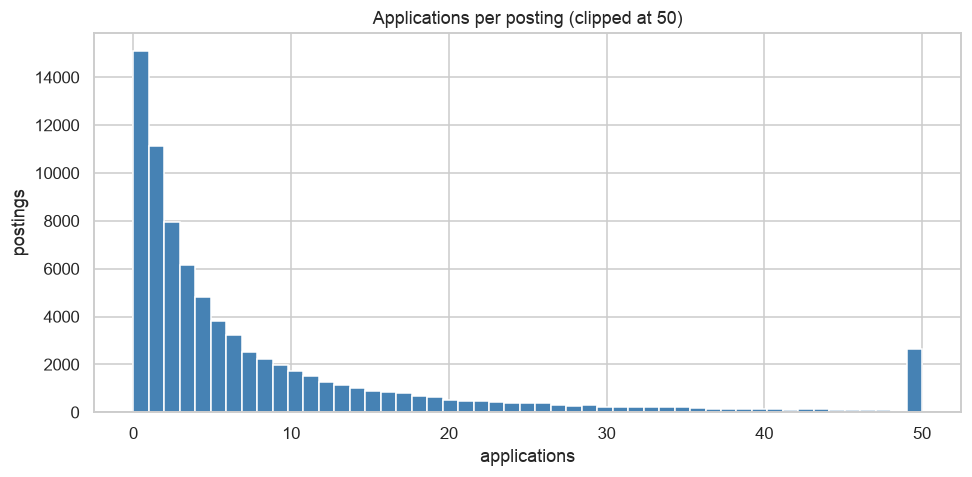

In [29]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(first.applications.clip(0, 50), bins=51, color='steelblue')
ax.set_title('Applications per posting (clipped at 50)')
ax.set_xlabel('applications')
ax.set_ylabel('postings')
plt.tight_layout()
plt.show()

This is why medians are the only honest summary: the mode is **zero** and the mean sits out past
the 70th percentile, dragged there by a tail of postings collecting hundreds of applications.

### 2.1 The same distribution, split by position level

Pay is charted in §3, which reports the same split alongside zero-application and under-filled
rates. Position level is not, so it is shown here. Boxes are drawn without outliers and the axis is
capped, because the tail above would otherwise flatten every box into a line.

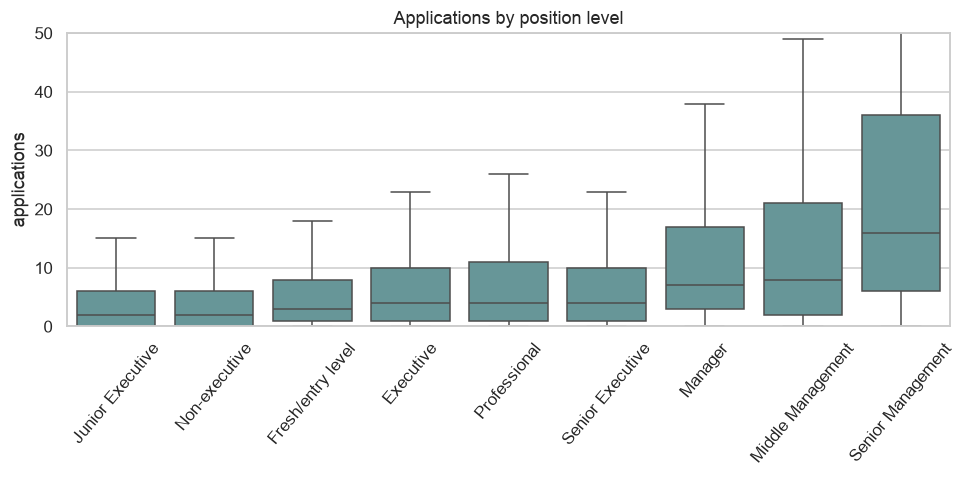

In [43]:
lvl_order = (first.groupby('position_level', observed=True).applications
                  .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=first, x='position_level', y='applications',
            order=lvl_order, showfliers=False, color='cadetblue', ax=ax)
ax.set_ylim(0, 50)
ax.set_title('Applications by position level')
ax.set_xlabel('')
ax.set_ylabel('applications')
ax.tick_params(axis='x', rotation=50)
plt.tight_layout()
plt.show()

## 3. Response benchmarks by configuration

The core deliverable: for a configuration, what response did comparable postings actually get?
Same graceful-degradation pattern as Layer 1 — quote the finest grain that clears `MIN_N`, and
always report which grain was used.

In [31]:
def response_benchmark(frame, keys, min_n=MIN_N):
    out = frame.groupby(keys, observed=True).agg(
        n=('applications', 'size'),
        apps_p10=('applications', lambda s: s.quantile(.10)),
        apps_p50=('applications', 'median'),
        apps_p90=('applications', lambda s: s.quantile(.90)),
        zero_rate=('applications', lambda s: (s == 0).mean()),
        under_filled=('under_filled', 'mean'),
        views_p50=('views', 'median'),
    ).round(3)
    return out[out.n >= min_n].sort_values('n', ascending=False)


KEYS_3 = ['sector', 'position_level', 'pay_band']
KEYS_2 = ['sector', 'position_level']

resp_3 = response_benchmark(first, KEYS_3)
resp_2 = response_benchmark(first, KEYS_2)

for name, tbl in [('sector+level+band', resp_3), ('sector+level', resp_2)]:
    print(f'{name:20s} {len(tbl):4d} cells >= {MIN_N}, covering {tbl.n.sum()/len(first):.1%} of postings')

resp_3.head(10)

sector+level+band     420 cells >= 30, covering 91.3% of postings
sector+level          247 cells >= 30, covering 98.2% of postings


n  apps_p10  apps_p50  apps_p90  zero_rate  under_filled  views_p50
sector                           position_level    pay_band                                                                                 
Admin / Secretarial              Junior Executive  Entry (< $3k)      1651       0.0       2.0      17.0      0.237         0.297       48.0
Building and Construction        Executive         Mid ($3-5k)        1381       0.0       2.0      12.0      0.182         0.396       83.0
Engineering                      Executive         Mid ($3-5k)        1370       0.0       2.0      12.1      0.223         0.304       52.0
Accounting / Auditing / Taxation Executive         Mid ($3-5k)        1304       0.0       5.0      20.0      0.142         0.213       83.0
Information Technology           Professional      Executive (> $8k)  1056       1.0       5.0      22.0      0.070         0.227       82.0
Admin / Secretarial              Fresh/entry level Entry (< $3k)      1017       0.0       4.0      26.0      0.153         0.238       75.0
                                 Non-executive     Entry (< $3k)       985       0.0       4.0      22.0      0.148         0.222       79.0
Engineering                      Junior Executive  Mid ($3-5k)         983       0.0       2.0      10.0      0.220         0.314       43.0
Admin / Secretarial              Executive         Mid ($3-5k)         979       1.0       8.0      35.0      0.080         0.122       87.0
Information Technology           Executive         Senior ($5-8k)      855       0.0       5.0      25.0      0.122         0.246       74.0

In [32]:
GLOBAL = {'n': len(first), 'apps_p10': first.applications.quantile(.10),
          'apps_p50': first.applications.median(), 'apps_p90': first.applications.quantile(.90),
          'zero_rate': (first.applications == 0).mean(), 'under_filled': first.under_filled.mean()}


def response_lookup(sector, position_level, pay_band=None):
    """Expected response for one configuration, degrading gracefully on thin cells."""
    if pay_band is not None and (sector, position_level, pay_band) in resp_3.index:
        return {'grain': 'sector + level + band', **resp_3.loc[(sector, position_level, pay_band)].to_dict()}
    if (sector, position_level) in resp_2.index:
        return {'grain': 'sector + level', **resp_2.loc[(sector, position_level)].to_dict()}
    return {'grain': 'all postings (no comparable cell)', **GLOBAL}


for q in [('Information Technology', 'Professional', 'Executive (> $8k)'),
          ('Admin / Secretarial', 'Junior Executive', 'Entry (< $3k)')]:
    r = response_lookup(*q)
    print(f'{q[0]} / {q[1]} / {q[2]}')
    print(f'   grain={r["grain"]}  n={int(r["n"]):,}  '
          f'median={r["apps_p50"]:.0f} applications (P10-P90: {r["apps_p10"]:.0f}-{r["apps_p90"]:.0f})')
    print(f'   {r["zero_rate"]:.0%} got zero applicants, {r["under_filled"]:.0%} under-filled\n')

Information Technology / Professional / Executive (> $8k)
   grain=sector + level + band  n=1,056  median=5 applications (P10-P90: 1-22)
   7% got zero applicants, 23% under-filled

Admin / Secretarial / Junior Executive / Entry (< $3k)
   grain=sector + level + band  n=1,651  median=2 applications (P10-P90: 0-17)
   24% got zero applicants, 30% under-filled



                       n  apps_p10  apps_p50  apps_p90  zero_rate  under_filled
pay_band                                                                       
Entry (< $3k)      21928       0.0       2.0      12.0      0.298         0.433
Mid ($3-5k)        32734       0.0       3.0      19.0      0.193         0.313
Senior ($5-8k)     15423       0.0       5.0      29.0      0.110         0.185
Executive (> $8k)   8345       1.0      10.0      51.0      0.057         0.126


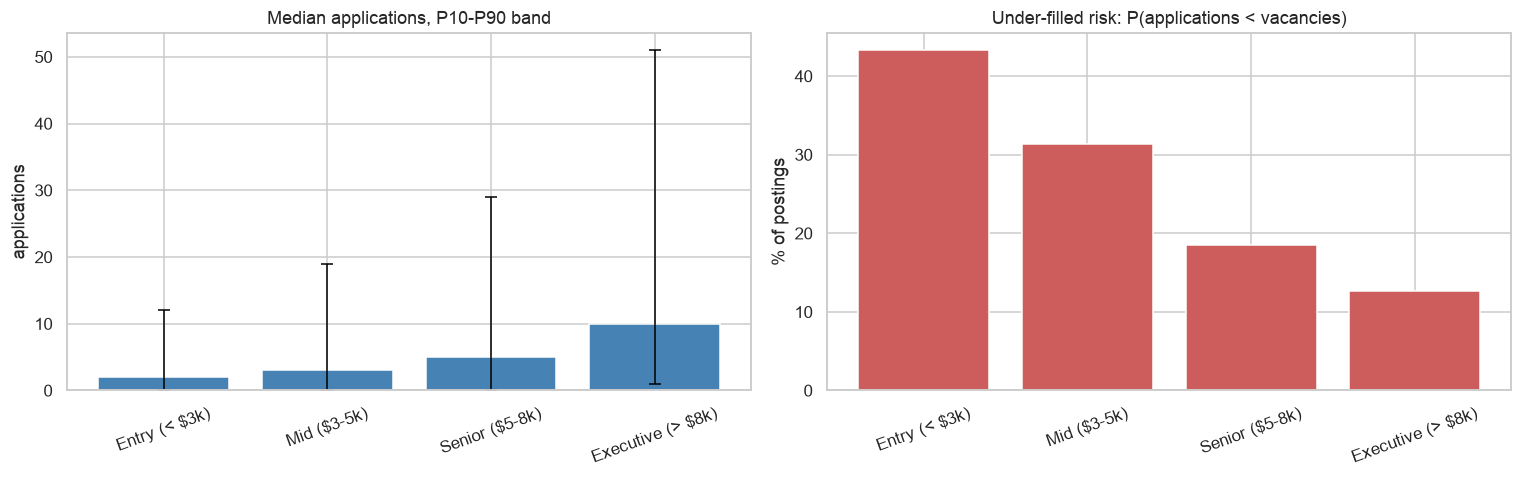

In [33]:
band_resp = first.groupby('pay_band', observed=True).agg(
    n=('applications', 'size'),
    apps_p10=('applications', lambda s: s.quantile(.10)),
    apps_p50=('applications', 'median'),
    apps_p90=('applications', lambda s: s.quantile(.90)),
    zero_rate=('applications', lambda s: (s == 0).mean()),
    under_filled=('under_filled', 'mean')).round(3)
print(band_resp.to_string())

plot_df = band_resp.loc[[b for b in PAY_LABELS if b in band_resp.index]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(plot_df))
axes[0].bar(x, plot_df.apps_p50, color='steelblue')
axes[0].errorbar(x, plot_df.apps_p50,
                 yerr=[plot_df.apps_p50 - plot_df.apps_p10, plot_df.apps_p90 - plot_df.apps_p50],
                 fmt='none', ecolor='black', capsize=4, lw=1)
axes[0].set_xticks(x); axes[0].set_xticklabels(plot_df.index, rotation=20)
axes[0].set_title('Median applications, P10-P90 band')
axes[0].set_ylabel('applications')

axes[1].bar(x, plot_df.under_filled * 100, color='indianred')
axes[1].set_xticks(x); axes[1].set_xticklabels(plot_df.index, rotation=20)
axes[1].set_title('Under-filled risk: P(applications < vacancies)')
axes[1].set_ylabel('% of postings')

plt.tight_layout()
plt.show()

Pay dominates response. Entry (< \$3k) postings get a median of **2** applicants and are
under-filled **43%** of the time; Executive (> \$8k) postings get a median of **10** and are
under-filled **13%**.

These bands are `pay_band` (§1.5) — cut on the actual midpoint, not the advertised ceiling — so
the comparison is between postings that really do pay differently. Layer 1's dollar percentiles
remain the finer instrument; bands are used here because splitting the data needs discrete groups.

## 4. The funnel — is it reach or is it conversion?

Applications are the product of two different things: how many people **saw** the posting, and what
share of them **applied**. They have different fixes. Low reach is a visibility problem; low
conversion means people looked at the offer and declined it.

In [34]:
first['conversion'] = first.applications / first.views.replace(0, np.nan)

funnel = first.groupby('pay_band', observed=True).agg(
    n=('views', 'size'),
    views_p50=('views', 'median'),
    conversion_p50=('conversion', 'median')).round(4)
funnel['conversion_%'] = (funnel.conversion_p50 * 100).round(2)
print(funnel.drop(columns='conversion_p50').to_string())

                       n  views_p50  conversion_%
pay_band                                         
Entry (< $3k)      21928       53.0          3.23
Mid ($3-5k)        32734       61.0          5.08
Senior ($5-8k)     15423       78.0          7.14
Executive (> $8k)   8345      116.0          8.89


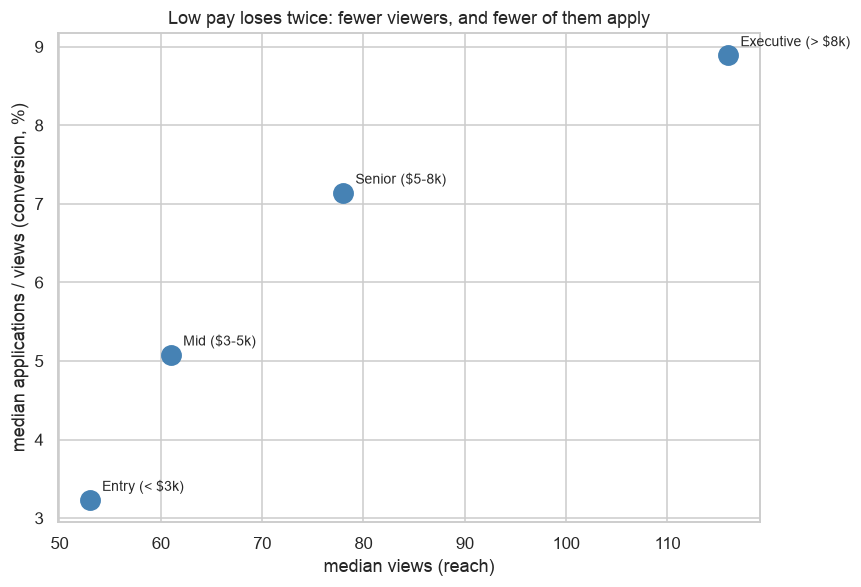

In [35]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sub = funnel.loc[[b for b in PAY_LABELS if b in funnel.index]]
ax.scatter(sub.views_p50, sub.conversion_p50 * 100, s=160, color='steelblue', zorder=3)
for label, row in sub.iterrows():
    ax.annotate(label, (row.views_p50, row.conversion_p50 * 100),
                textcoords='offset points', xytext=(8, 6), fontsize=9)
ax.set_xlabel('median views (reach)')
ax.set_ylabel('median applications / views (conversion, %)')
ax.set_title('Low pay loses twice: fewer viewers, and fewer of them apply')
plt.tight_layout()
plt.show()

The two effects compound rather than trade off. Entry-band postings get about **half** the views of
Executive-band ones (53 vs 116) *and* convert at roughly **a third** the rate (3.2% vs 8.9%).

For the dashboard this is the more actionable split: if a configuration's problem is conversion,
raising the salary is the lever. If it is reach, the sector is simply crowded — which is what
Layer 1's competition-density measure quantifies.

## 5. Repost risk — where the overall view is actively wrong

Now the stated business outcome. The naive cut says: **require more experience, get fewer
reposts.** Taken at face value that advises the hirer to raise the experience bar to protect the
fill — which would be a bad thing for a dashboard to imply.

In [36]:
repost_pool = repost_pool.copy()
repost_pool['yrs'] = pd.cut(repost_pool.seniority_years, YR_BINS, labels=YR_LABELS)

overall = repost_pool.groupby('yrs', observed=True).agg(
    n=('is_repost', 'size'), repost_rate=('is_repost', 'mean')).round(3)
print('OVERALL (not split by pay) -- repost rate by required years:')
print(overall.to_string())
print('\nReads as: more experience -> fewer reposts. Now hold pay fixed.')

OVERALL (not split by pay) -- repost rate by required years:
         n  repost_rate
yrs                    
0     9757        0.202
1    25848        0.174
2    21085        0.200
3    15919        0.185
4-5  15707        0.156
6-8   4552        0.138
9+    3160        0.117

Reads as: more experience -> fewer reposts. Now hold pay fixed.


In [37]:
# The naive table above, restated as a single odds ratio -- then the same odds ratio
# with pay held fixed. Mantel-Haenszel pools the within-band tables directly.
# The frame, the 2x2 helper and the stratified table are all reused by s.6.
exp_pay = repost_pool[repost_pool.pay_band.notna()].copy()
exp_pay['hi_exp'] = (exp_pay.seniority_years.clip(0, 15) >= 3).astype(int)


def two_by_two(frame):
    """2x2 of hi_exp (>=3yr) against is_repost, oriented [exposed, unexposed] x [case, non-case]."""
    return (pd.crosstab(frame.hi_exp, frame.is_repost.astype(int))
              .reindex(index=[1, 0], columns=[1, 0]).fillna(0).values)


crude = two_by_two(exp_pay)
crude_or = (crude[0, 0] * crude[1, 1]) / (crude[0, 1] * crude[1, 0])
mh_table = StratifiedTable(np.dstack([two_by_two(g)
                                      for _, g in exp_pay.groupby('pay_band', observed=True)]))

print(f'n = {len(exp_pay):,} postings carrying a pay band\n')
print(f'crude odds ratio (>=3yr vs <3yr)  {crude_or:.3f}   <- "more experience -> less reposting"')
print(f'same, with pay band held fixed    {mh_table.oddsratio_pooled:.3f}   '
      f'(p = {mh_table.test_null_odds().pvalue:.2f})   <- the effect vanishes')

n = 95,289 postings carrying a pay band

crude odds ratio (>=3yr vs <3yr)  0.838   <- "more experience -> less reposting"
same, with pay band held fixed    0.989   (p = 0.58)   <- the effect vanishes


Holding pay fixed, the apparent protective effect of demanding experience is **gone** — the odds
ratio moves from 0.838 to 0.989, indistinguishable from 1. The naive reading was pay in disguise.

That is the confounding in two numbers, and it is only half the story. The heatmap below shows the
other half, and the reason 0.989 should not be reported on its own: it is an *average* over bands
that disagree in sign.

Cell counts behind the heatmap (blank cells below are hidden, fewer than 30):
yrs                   0      1      2     3   4-5   6-8    9+
pay_band                                                     
Entry (< $3k)      5824  13664   5704  1661   441    27    13
Mid ($3-5k)        3029  10281  12312  8789  4971   419   260
Senior ($5-8k)      477   1382   2576  4389  7189  1719   644
Executive (> $8k)   173    267    395  1033  3066  2360  2224


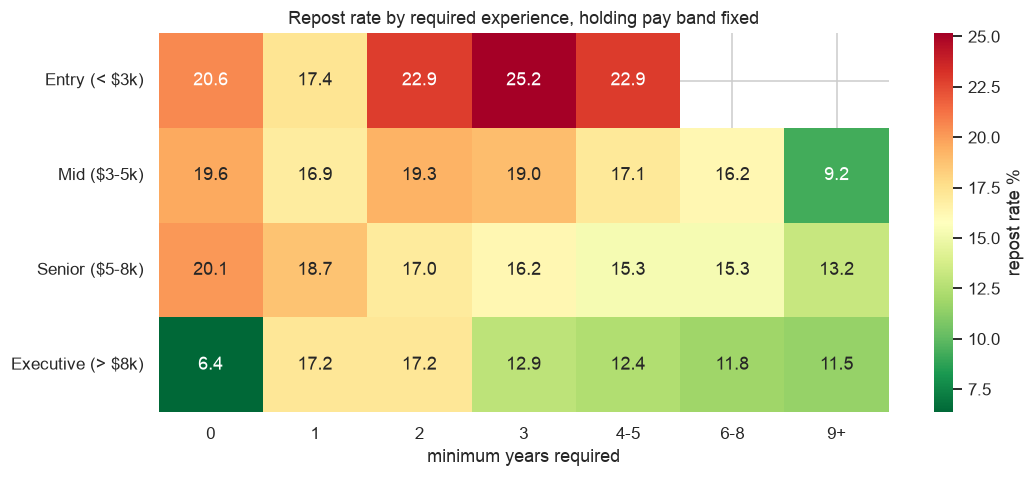

In [38]:
strat = pd.crosstab(repost_pool.pay_band, repost_pool.yrs,
                    values=repost_pool.is_repost, aggfunc='mean')
counts = pd.crosstab(repost_pool.pay_band, repost_pool.yrs)
strat = strat.where(counts >= MIN_N)          # suppress cells too thin to read
strat = strat.loc[[b for b in PAY_LABELS if b in strat.index]]

print(f'Cell counts behind the heatmap (blank cells below are hidden, fewer than {MIN_N}):')
print(counts.loc[strat.index].to_string())

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(strat * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'repost rate %'}, ax=ax)
ax.set_title('Repost rate by required experience, holding pay band fixed')
ax.set_xlabel('minimum years required')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

The overall trend dissolves, and inside the Entry band it **reverses**: asking for more experience
at low pay is associated with *more* reposting, peaking at 3 years. In the Senior band the
relationship runs the other way, falling steadily as required years rise. Mid sits between the two:
its rates drift down only at the far experience tail, and §6 shows its ≥3-year contrast is null —
a transition band, not a third trend.

The overall decline was a mix effect: senior-experience roles are concentrated in higher pay
bands, and those bands repost less. Aggregating across bands mixes the two and inverts the sign —
a textbook Simpson's paradox, and the reason a dashboard must not ship the un-split view.

**The danger zone is high experience demanded at low pay.**

**Two honest qualifications on the table above.**

1. The Entry band's tail is thin. Its 6–8 and 9+ cells were hidden at 27 and 13 postings.
   Employers rarely ask for a decade of experience at under \$3k, which is itself informative — but
   it means the rise is established over the 0–5 year span only, not across the full range. The
   *direction* is what survives, and §6 tests it on all 95,289 postings.
2. The Executive band's low-experience cells are thin and erratic (n = 173 at 0 years, 267 at 1
   year) and should not be read as a trend. Well-paid roles asking almost no experience are rare
   enough that the cell is noisy; it does not affect the main finding.

## 6. Confirming it with a significance test

§5 read the reversal off a heatmap. What is still missing is a **test**: is the Entry-band rise
bigger than noise, and does the effect genuinely *differ* between bands rather than just looking
different?

Both questions are about one contrast — postings demanding **≥3 years** against those demanding
fewer — so the table below reports that contrast within each pay band, and **Breslow–Day** asks
whether the four odds ratios are all the same. That single test is the interaction claim itself.

Read the **95% CI** column rather than the p-values: an interval sitting entirely above 1 means
demanding experience goes with *more* reposting, entirely below 1 means less, and one that straddles
1 means the data cannot tell.

In [39]:
# Same frame, helper and stratified table as s.5 -- here split out band by band
# instead of pooled, then tested for heterogeneity.
rows = []
for band in PAY_LABELS:
    g = exp_pay[exp_pay.pay_band == band]
    t2 = Table2x2(two_by_two(g))
    lo, hi = g[g.hi_exp == 0].is_repost.mean(), g[g.hi_exp == 1].is_repost.mean()
    ci_lo, ci_hi = t2.oddsratio_confint()
    rows.append({'pay_band': band, 'n': len(g),
                 'repost% <3yr': round(lo * 100, 1), 'repost% >=3yr': round(hi * 100, 1),
                 'diff_pp': round((hi - lo) * 100, 1), 'odds_ratio': round(t2.oddsratio, 3),
                 '95% CI': f'{ci_lo:.2f}-{ci_hi:.2f}', 'p': f'{t2.oddsratio_pvalue():.1e}'})
print(pd.DataFrame(rows).to_string(index=False))

bd = mh_table.test_equal_odds()
print('\nBreslow-Day test -- are those four odds ratios all the same?')
print(f'   chi2 = {bd.statistic:.1f} on {len(PAY_LABELS) - 1} df,  p = {bd.pvalue:.1e}')

         pay_band     n  repost% <3yr  repost% >=3yr  diff_pp  odds_ratio    95% CI       p
    Entry (< $3k) 27334          19.4           24.6      5.3       1.362 1.23-1.51 4.2e-09
      Mid ($3-5k) 40061          18.4           18.1     -0.3       0.980 0.93-1.03 4.5e-01
   Senior ($5-8k) 18376          17.9           15.5     -2.4       0.842 0.77-0.92 1.7e-04
Executive (> $8k)  9518          15.0           12.1     -2.9       0.780 0.64-0.95 1.5e-02

Breslow-Day test -- are those four odds ratios all the same?
   chi2 = 55.3 on 3 df,  p = 5.9e-12


The confidence intervals separate cleanly. **Entry sits at 1.36 (1.23–1.51), entirely above 1** —
at low pay, demanding 3+ years goes with *more* reposting. **Senior (0.77–0.92) and Executive
(0.64–0.95) sit entirely below 1.** Mid straddles 1 at 0.98, which is what a transition band should
look like. Breslow–Day rejects a common odds ratio at **p = 6e-12**, so the bands genuinely differ —
the interaction is not an artefact of eyeballing the heatmap.

**A necessary caveat: the effect is real but small.** Inside the Entry band, demanding ≥3 years
moves the repost rate from **19.4% to 24.6%** — about 1 posting in 20. Roughly three-quarters of
high-experience Entry-band postings still do not get reposted. Whether an employer reposts is
driven overwhelmingly by factors this dataset does not contain (hiring urgency, candidate quality,
internal process). What this establishes is the **direction and significance of an interaction**,
not an ability to predict which postings will be reposted. The dashboard should present this as a
risk factor, never as a prediction.

## 7. How the variables move together

A cross-check rather than a step in the argument: §5–6 are already settled, and this section steps
back to see how the variables sit relative to one another. It runs on the counters-complete set
(§1.1), before the 30-day and first-cycle restrictions, so that `listing_days` and `repost_count`
still vary.

**Spearman, not Pearson.** The outcomes are heavily skewed (`applications` 8.5, `vacancies` 66.6),
and two columns enter as ranks, where Pearson would wrongly assume evenly spaced levels. It matters:
`company_postings` × `views` reads **−0.53** by Spearman and only **−0.23** by Pearson. The cost is
that Spearman sees monotone relationships only — a U-shaped one would read as zero here.

Five of the columns in the matrix are not numeric and cannot enter a correlation as they stand, so
each is given an explicit reading:

| column | entered as |
|---|---|
| `position_level` | rank, ordered by that level's median `seniority_years` |
| `experience_level` | rank, Entry Level < Mid Level < Senior |
| `job_type` | binary, Permanent or Full Time = 1 (8 unordered categories otherwise) |
| `company` | **replaced** by `company_postings` — how many postings that company ran within this frame. 19,895 distinct employers cannot be ranked, but posting volume can |
| `metadata_isPostedOnBehalf` | binary |

n = 118,749 counters-complete postings
position_level ranked as: Fresh/entry level < Junior Executive < Non-executive < Executive < Professional < Senior Executive < Manager < Middle Management < Senior Management


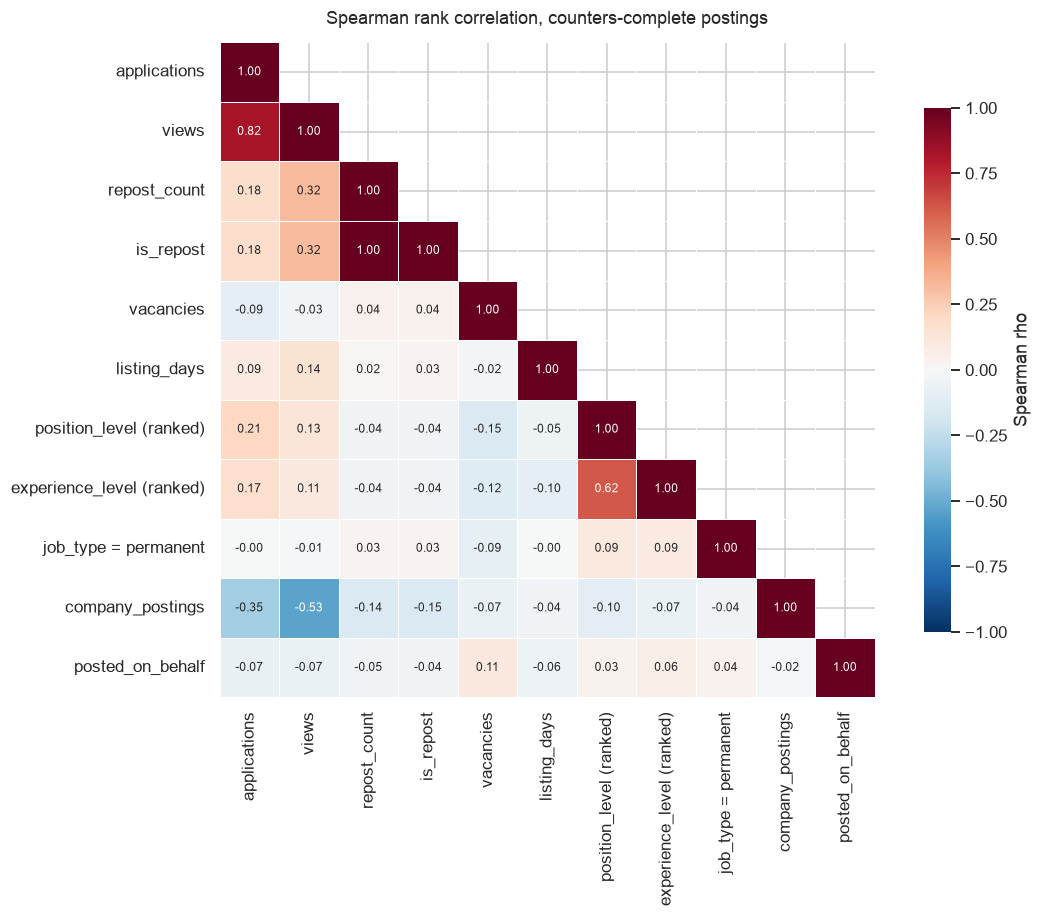

In [40]:
seniority_rank_order = (settled.groupby('position_level', observed=True).seniority_years
                    .median().sort_values().index.tolist())
EXP_ORDER = ['Entry Level', 'Mid Level', 'Senior']
SECURE = ['Permanent', 'Full Time']

cm = pd.DataFrame({
    'applications':             settled.applications,
    'views':                    settled.views,
    'repost_count':             settled.repost_count,
    'is_repost':                settled.is_repost.astype(int),
    'vacancies':                settled.vacancies,
    'listing_days':             settled.listing_days,
    'position_level (ranked)':  settled.position_level.map({v: i for i, v in enumerate(seniority_rank_order)}),
    'experience_level (ranked)':settled.experience_level.map({v: i for i, v in enumerate(EXP_ORDER)}),
    'job_type = permanent':     settled.job_type.isin(SECURE).astype(int),
    'company_postings':         settled.company.map(settled.company.value_counts()),
    'posted_on_behalf':         settled.metadata_isPostedOnBehalf.astype(int),
}).astype('float64')

corr = cm.corr(method='spearman')
print(f'n = {len(cm):,} counters-complete postings')
print('position_level ranked as: ' + ' < '.join(seniority_rank_order))

fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, linewidths=.5,
            annot_kws={'size': 8}, cbar_kws={'label': 'Spearman rho', 'shrink': .8}, ax=ax)
ax.set_title('Spearman rank correlation, counters-complete postings', pad=12)
plt.tight_layout()
plt.show()

**Four things worth reading off it.**

1. **`applications`–`views` = 0.82.** The funnel of §4: applications are mostly a function of reach.
   The residual is conversion, which is where pay acts.

2. **`company_postings`–`views` = −0.53** (and −0.35 against applications) — the strongest
   *negative* association in the matrix and one nothing else in this notebook measures. Employers
   that post a lot get markedly less engagement *per posting*. That is consistent with high-volume
   recruitment agencies, and `posted_on_behalf` is the weak version of the same signal. Worth a look
   in Layer 3.

3. **`repost_count`–`views` = 0.32 and `listing_days`–`views` = 0.14** are the two confounds §1
   exists to remove — accumulated exposure across cycles (§1.3) and unequal exposure windows (§1.2).
   Seeing them here is the retrospective case for those filters: on the unfiltered set they are
   large enough to distort any comparison of configurations.

4. **`position_level`–`experience_level` = 0.62.** The two seniority variables are largely
   redundant, which is why §3 benchmarks on `position_level` alone rather than both.

**One caveat on reading this matrix at all.** `repost_count` and `is_repost` are the same variable
(the second is the first thresholded), so their 1.00 is arithmetic, not a finding. More generally,
every cell here is a *marginal* association — the entire point of §5 is that the experience/repost
relationship inverts once pay is held fixed, and no correlation matrix can show that. Use this for
orientation, not for conclusions.

## 8. Conclusions — and the limits

**1. Response is low in absolute terms, and the mean conceals it.**
Across the 78,942 first-cycle postings the median receives **3** applications against a mean of
**9.6**. **19.1%** receive none at all, **30.1%** draw fewer applicants than they have vacancies,
and **17.8%** of the 30-day pool is reposted. A dashboard quoting averages would set hirer
expectations roughly three times too high.

**2. Pay is the dominant lever, and it works twice over.**
Entry (< \$3k) postings draw a median of **2** applications and are under-filled **43.3%** of the
time; Executive (> \$8k) postings draw **10** and are under-filled **12.6%**. The mechanism is two
compounding effects rather than one: Entry postings get **53** median views against Executive's
**116** (reach) *and* convert those views at **3.2%** against **8.9%** (conversion). Pay moves both,
which is why the gap in outcomes is so much wider than the gap in either component.

**3. The experience–repost relationship inverts once pay is held fixed.**
Unsplit, requiring more experience looks protective — odds ratio **0.838**. Hold pay fixed and it
vanishes (**0.989**), and that null turns out to be an average over bands that disagree in sign.
Inside the Entry band the relationship reverses, peaking at **25.2%** where 3 years are demanded
against **20.6%** at 0; in the Senior band it falls steadily, **20.1%** down to **13.2%**. Testing the
≥3-year contrast directly, the Entry-band odds ratio is **1.36 (95% CI 1.23–1.51)** while Senior
(0.77–0.92) and Executive (0.64–0.95) sit entirely below 1 and Mid straddles it at 0.98. Breslow–Day
rejects a common odds ratio at **p = 6e-12**.

This is Simpson's paradox, and it carries a direct product consequence: **the un-split view must not
ship**. Shown without the pay split it tells a hirer the opposite of what the data supports.

**4. The actionable risk is high experience demanded at low pay.**
That is the one region where asking for more experience measurably *raises* reposting instead of
lowering it — and it is the cell a hirer is most likely to land in by accident, since demanding
experience feels costless at the point of writing the posting.

---

**What this notebook cannot establish.**

* **Anything seasonal or recent.** The cohort is a single window, Mar–Jun 2023. Layer 1 covers 15
  months; Layer 2 does not, and no amount of care fixes that.
* **Causation.** These are associations. A configuration is chosen by an employer who knows things
  about the role that we do not.
* **Whether a role actually filled.** We observe applications, not hires. "Under-filled" is a
  necessary-not-sufficient stand-in.
* **Prediction of reposting.** The largest effect found is ~5 percentage points on a 19.4% base;
  roughly three-quarters of high-experience Entry-band postings are still not reposted. Reposting is
  driven overwhelmingly by factors this dataset does not record — hiring urgency, candidate quality,
  internal process. Risk factors, never predictions.

**Coverage note.** Every filter in §1 is documented with its row cost: 1,009,709 deduplicated
postings, 118,749 complete-counter, 96,028 after the 30-day restriction, 78,942 first-cycle.
Nothing was dropped silently.